# TAE-IA · Module 6 · L20 — Whisper in Practice: Timestamps and Subtitles

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L20 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU |
| **Drive space** | ~0 MB new (reuses Whisper weights from L19) |

## Learning objectives

1. Extract segment-level and word-level timestamps from Whisper
2. Write correctly formatted SRT and VTT subtitle files
3. Chunk a long audio file manually with overlap + deduplication
4. Filter hallucinated segments using `no_speech_prob`
5. Build a one-file Gradio subtitle-generation app

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, time, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')
print(f'Device: {DEVICE}')

Mounted at /content/drive
GPU: Tesla T4
Device: cuda


In [2]:
!pip install openai-whisper gtts librosa soundfile gradio -q

import whisper
import librosa
import soundfile as sf
from gtts import gTTS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'whisper {whisper.__version__}')

# Load Whisper small — reuses Drive cache from L19
print('\nLoading Whisper small from Drive cache...')
t0 = time.time()
model = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    model = model.to('cuda')
print(f'Loaded in {time.time()-t0:.1f}s')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 43.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 1.16.1 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
whisper 20250625

Loading Whisper small from Drive cache...
Loaded in 22.6s


---
## Section 1 — Helper Functions

Define all helpers up front so every section below can call them.

In [3]:
# ================================================================
# Section 1 — Helper Functions (corrected)
# ================================================================

def seconds_to_srt_time(seconds):
    """Convert seconds to an SRT timecode: HH:MM:SS,mmm."""
    total_ms = int(round(max(0.0, float(seconds)) * 1000))

    hours, remainder = divmod(total_ms, 3_600_000)
    minutes, remainder = divmod(remainder, 60_000)
    seconds, milliseconds = divmod(remainder, 1000)

    return f'{hours:02d}:{minutes:02d}:{seconds:02d},{milliseconds:03d}'


def seconds_to_vtt_time(seconds):
    """Convert seconds to a VTT timecode: HH:MM:SS.mmm."""
    return seconds_to_srt_time(seconds).replace(',', '.')


def split_subtitle_text(text, max_chars=42, max_lines=2):
    """
    Wrap text and divide it into subtitle cues without discarding words.
    Each cue contains at most max_lines.
    """
    words = text.split()
    if not words:
        return []

    lines = []
    current_line = ''

    for word in words:
        candidate = f'{current_line} {word}'.strip()

        if current_line and len(candidate) > max_chars:
            lines.append(current_line)
            current_line = word
        else:
            current_line = candidate

    if current_line:
        lines.append(current_line)

    return [
        '\n'.join(lines[i:i + max_lines])
        for i in range(0, len(lines), max_lines)
    ]


def segment_to_cues(segment, max_chars=42, max_lines=2):
    """
    Split one Whisper segment into one or more subtitle cues.
    The original time interval is distributed according to word count.
    """
    text = segment['text'].strip()

    if not text:
        return []

    blocks = split_subtitle_text(text, max_chars, max_lines)

    start = float(segment['start'])
    end = float(segment['end'])

    if end <= start:
        end = start + 0.001

    duration = end - start
    word_counts = [
        max(1, len(block.replace('\n', ' ').split()))
        for block in blocks
    ]
    total_words = sum(word_counts)

    cues = []
    accumulated_words = 0

    for i, (block, n_words) in enumerate(zip(blocks, word_counts)):
        cue_start = start + duration * accumulated_words / total_words
        accumulated_words += n_words

        cue_end = (
            end if i == len(blocks) - 1
            else start + duration * accumulated_words / total_words
        )

        cues.append({
            'start': cue_start,
            'end': cue_end,
            'text': block
        })

    return cues


def segments_to_srt(segments, max_chars=42, max_lines=2,
                    skip_silence=True):
    """Convert Whisper segments to a complete SRT string."""
    blocks = []
    counter = 1

    for segment in segments:
        no_speech = segment.get('no_speech_prob', 0.0)

        if skip_silence and no_speech > 0.6:
            continue

        cues = segment_to_cues(segment, max_chars, max_lines)

        for cue in cues:
            start_tc = seconds_to_srt_time(cue['start'])
            end_tc = seconds_to_srt_time(cue['end'])

            blocks.append(
                f"{counter}\n"
                f"{start_tc} --> {end_tc}\n"
                f"{cue['text']}"
            )
            counter += 1

    return '\n\n'.join(blocks) + '\n'


def segments_to_vtt(segments, max_chars=42, max_lines=2,
                    skip_silence=True):
    """Convert Whisper segments to a complete WebVTT string."""
    blocks = ['WEBVTT']

    for segment in segments:
        no_speech = segment.get('no_speech_prob', 0.0)

        if skip_silence and no_speech > 0.6:
            continue

        cues = segment_to_cues(segment, max_chars, max_lines)

        for cue in cues:
            start_tc = seconds_to_vtt_time(cue['start'])
            end_tc = seconds_to_vtt_time(cue['end'])

            blocks.append(
                f"{start_tc} --> {end_tc}\n"
                f"{cue['text']}"
            )

    return '\n\n'.join(blocks) + '\n'


print('Subtitle helper functions defined correctly.')

Subtitle helper functions defined correctly.


---
## Section 2.1 — Timestamps from a Multi-sentence Recording

Generate a TTS narration with 5 sentences that each cover a distinct topic, then compare segment vs. word timestamps.

In [4]:
NARRATION = (
    "Audio signals are the foundation of speech and music processing. "
    "Fourier analysis decomposes a signal into its frequency components. "
    "The mel scale aligns frequency representation with human auditory perception. "
    "Convolutional neural networks treat spectrograms as two-dimensional images. "
    "Whisper processes audio in thirty-second windows using an encoder-decoder architecture."
)

NARRATION_PATH = '/tmp/narration.mp3'
tts = gTTS(text=NARRATION, lang='en')
tts.save(NARRATION_PATH)

y_narr, sr_narr = librosa.load(NARRATION_PATH, sr=16000, mono=True)
print(f'Narration: {len(y_narr)/sr_narr:.1f}s')
ipd.display(ipd.Audio(y_narr, rate=sr_narr))

Narration: 27.3s


In [5]:
# --- Segment-level timestamps (default) ---
print('Transcribing with segment timestamps...')
result_seg = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'))

print(f'\nDetected language: {result_seg["language"]}')
print(f'Segments: {len(result_seg["segments"])}\n')
print('Segment timeline:')
for seg in result_seg['segments']:
    prob = seg.get('no_speech_prob', 0)
    flag = ' [SILENCE?]' if prob > 0.4 else ''
    print(f"  [{seg['start']:5.2f}s → {seg['end']:5.2f}s]  "
          f"conf={seg['avg_logprob']:.2f}  "
          f"no_speech={prob:.2f}{flag}")
    print(f"    {seg['text'].strip()}")

Transcribing with segment timestamps...

Detected language: en
Segments: 5

Segment timeline:
  [ 0.00s →  4.40s]  conf=-0.15  no_speech=0.02
    Audio signals are the foundation of speech and music processing.
  [ 4.40s →  9.52s]  conf=-0.15  no_speech=0.02
    Fourier analysis decomposes a signal into its frequency components.
  [ 9.52s → 15.12s]  conf=-0.15  no_speech=0.02
    The Mell scale aligns frequency representation with human auditory perception.
  [15.12s → 20.56s]  conf=-0.15  no_speech=0.02
    Convolutional neural networks treat spectrograms as two-dimensional images.
  [20.56s → 26.24s]  conf=-0.15  no_speech=0.02
    Whisper processes audio in 30-second windows using an encoder-decoder architecture.


In [6]:
# --- Word-level timestamps ---
print('Transcribing with word timestamps (slower)...')
t0 = time.time()
result_word = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'),
                               word_timestamps=True)
print(f'Done in {time.time()-t0:.2f}s\n')

# Print word timeline for the first 2 segments
for seg in result_word['segments'][:2]:
    print(f"Segment: \"{seg['text'].strip()}\"")
    for w in seg.get('words', []):
        print(f"  {w['start']:5.2f}–{w['end']:5.2f}  {w['word']!r:<20}  p={w['probability']:.2f}")
    print()

Transcribing with word timestamps (slower)...
Done in 13.66s

Segment: "Audio signals are the foundation of speech and music processing."
   0.00– 0.40  ' Audio'              p=0.93
   0.40– 0.86  ' signals'            p=0.89
   0.86– 1.18  ' are'                p=1.00
   1.18– 1.32  ' the'                p=1.00
   1.32– 1.76  ' foundation'         p=1.00
   1.76– 2.16  ' of'                 p=1.00
   2.16– 2.48  ' speech'             p=1.00
   2.48– 2.72  ' and'                p=0.99
   2.72– 3.06  ' music'              p=1.00
   3.06– 3.76  ' processing.'        p=1.00

Segment: "Fourier analysis decomposes a signal into its frequency components."
   4.44– 4.80  ' Fourier'            p=0.80
   4.80– 5.58  ' analysis'           p=0.89
   5.58– 6.48  ' decomposes'         p=1.00
   6.48– 6.74  ' a'                  p=1.00
   6.74– 7.10  ' signal'             p=1.00
   7.10– 7.44  ' into'               p=1.00
   7.44– 7.68  ' its'                p=0.99
   7.68– 8.12  ' frequency'       

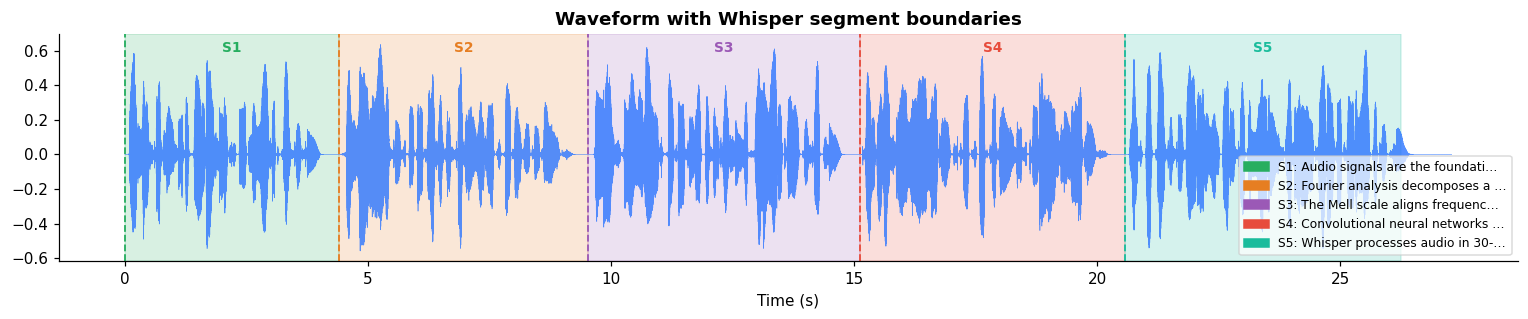

In [7]:
# Visualise the waveform with segment boundaries overlaid
fig, ax = plt.subplots(figsize=(14, 3))

t_axis = np.linspace(0, len(y_narr)/sr_narr, len(y_narr))
ax.plot(t_axis, y_narr, color='#2C75FF', linewidth=0.4, alpha=0.8)

colours = ['#27ae60', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
patches = []
for i, seg in enumerate(result_seg['segments']):
    c = colours[i % len(colours)]
    ax.axvspan(seg['start'], seg['end'], alpha=0.18, color=c)
    ax.axvline(seg['start'], color=c, linewidth=1.2, linestyle='--')
    mid = (seg['start'] + seg['end']) / 2
    ax.text(mid, ax.get_ylim()[1]*0.85, f'S{i+1}',
            ha='center', fontsize=9, color=c, fontweight='bold')
    patches.append(mpatches.Patch(color=c, label=f'S{i+1}: {seg["text"].strip()[:30]}…'))

ax.set_xlabel('Time (s)')
ax.set_title('Waveform with Whisper segment boundaries', fontweight='bold')
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Write and Validate SRT and VTT Files

In [8]:
srt_content = segments_to_srt(result_seg['segments'])
vtt_content = segments_to_vtt(result_seg['segments'])

print('=== SRT ===')
print(srt_content)
print()
print('=== VTT ===')
print(vtt_content)

=== SRT ===
1
00:00:00,000 --> 00:00:04,400
Audio signals are the foundation of speech
and music processing.

2
00:00:04,400 --> 00:00:09,520
Fourier analysis decomposes a signal into
its frequency components.

3
00:00:09,520 --> 00:00:14,560
The Mell scale aligns frequency
representation with human auditory

4
00:00:14,560 --> 00:00:15,120
perception.

5
00:00:15,120 --> 00:00:20,560
Convolutional neural networks treat
spectrograms as two-dimensional images.

6
00:00:20,560 --> 00:00:25,672
Whisper processes audio in 30-second
windows using an encoder-decoder

7
00:00:25,672 --> 00:00:26,240
architecture.


=== VTT ===
WEBVTT

00:00:00.000 --> 00:00:04.400
Audio signals are the foundation of speech
and music processing.

00:00:04.400 --> 00:00:09.520
Fourier analysis decomposes a signal into
its frequency components.

00:00:09.520 --> 00:00:14.560
The Mell scale aligns frequency
representation with human auditory

00:00:14.560 --> 00:00:15.120
perception.

00:00:15.120 --> 00:00:20.56

In [9]:
SRT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.srt'
VTT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.vtt'

with open(SRT_OUT, 'w', encoding='utf-8') as f:
    f.write(srt_content)
with open(VTT_OUT, 'w', encoding='utf-8') as f:
    f.write(vtt_content)

print(f'SRT: {SRT_OUT}')
print(f'VTT: {VTT_OUT}')

SRT: /content/drive/MyDrive/TAE_IA_M6/narration.srt
VTT: /content/drive/MyDrive/TAE_IA_M6/narration.vtt


In [10]:
import re

def validate_srt(srt_string):
    """Basic structural validation of an SRT string. Returns list of errors."""
    errors = []
    blocks = [b.strip() for b in re.split(r'\n\n+', srt_string.strip()) if b.strip()]
    TC = re.compile(r'^(\d{2}:\d{2}:\d{2},\d{3}) --> (\d{2}:\d{2}:\d{2},\d{3})$')

    for idx, block in enumerate(blocks):
        lines = block.split('\n')
        if not lines[0].strip().isdigit():
            errors.append(f'Block {idx+1}: first line is not a counter: {lines[0]!r}')
        if len(lines) < 3:
            errors.append(f'Block {idx+1}: too few lines ({len(lines)})')
            continue
        m = TC.match(lines[1])
        if not m:
            errors.append(f'Block {idx+1}: bad timecode: {lines[1]!r}')
        else:
            def tc_to_ms(tc):
                h, rest = tc.split(':', 1)
                mi, rest2 = rest.split(':', 1)
                s, ms = rest2.split(',')
                return int(h)*3600000 + int(mi)*60000 + int(s)*1000 + int(ms)
            if tc_to_ms(m.group(1)) >= tc_to_ms(m.group(2)):
                errors.append(f'Block {idx+1}: start >= end: {lines[1]}')

    return errors if errors else ['OK — no errors found']

print('SRT validation:')
for msg in validate_srt(srt_content):
    print(f'  {msg}')

SRT validation:
  OK — no errors found


---
## Section 2.3 — Chunking a Long Audio File

Build a ~2-minute TTS lecture from 5 topic paragraphs separated by 3 seconds of silence, then transcribe it using manual 30-second chunking with 1-second overlap.

In [11]:
TOPICS = [
    ("In this lecture, we explore the fundamentals of digital audio processing. "
     "Every audio signal is a sequence of pressure samples captured at a fixed rate. "
     "The sample rate determines the highest frequency that can be faithfully represented. "
     "For human speech, sixteen thousand samples per second is sufficient."),

    ("The Fourier transform is the key mathematical tool for audio analysis. "
     "It decomposes a time-domain signal into a sum of sinusoids at different frequencies. "
     "The short-time Fourier transform applies this analysis to overlapping short windows, "
     "producing a two-dimensional time-frequency representation called a spectrogram."),

    ("The mel scale was designed to match human auditory perception. "
     "Humans perceive pitch differences logarithmically at high frequencies. "
     "A mel filterbank applies triangular filters spaced according to this scale, "
     "compressing the frequency axis to highlight perceptually important differences."),

    ("Deep learning models for audio classification treat spectrograms as images. "
     "A convolutional neural network scans the spectrogram with learned filters, "
     "detecting frequency patterns that correspond to sound categories. "
     "Transfer learning from ImageNet-trained models accelerates training significantly."),

    ("Whisper is an encoder-decoder transformer trained on six hundred thousand hours of audio. "
     "The encoder converts a thirty-second mel spectrogram into contextual embeddings. "
     "The decoder attends to these embeddings and generates text tokens autoregressively. "
     "This architecture supports transcription in ninety-nine languages simultaneously."),
]

print('Generating the long TTS lecture...')
chunks_audio = []
for i, topic in enumerate(TOPICS):
    tts = gTTS(text=topic, lang='en')
    tmp = f'/tmp/topic_{i}.mp3'
    tts.save(tmp)
    y, _ = librosa.load(tmp, sr=16000, mono=True)
    chunks_audio.append(y)
    print(f'  Topic {i+1}: {len(y)/16000:.1f}s')

# 3s silence between topics. Long enough that Whisper treats a gap as its own
# segment -- which is what gives Section 2.3's no_speech_prob filter something
# to act on. Watch what it decides to throw away.
silence = np.zeros(int(3.0 * 16000), dtype=np.float32)
y_long  = np.concatenate([x for chunk in chunks_audio for x in [chunk, silence]])
LONG_WAV = '/tmp/lecture_long.wav'
sf.write(LONG_WAV, y_long, 16000)
print(f'\nTotal duration: {len(y_long)/16000:.1f}s  →  {LONG_WAV}')

# Listen to it. It is long, so use the scrubber -- but do land on a few of the
# 3-second gaps between topics: those are what the no_speech_prob filter in
# Section 2.3 decides about, and one of them sits right on a chunk seam.
ipd.display(ipd.Audio(y_long, rate=16000))

Generating the long TTS lecture...
  Topic 1: 21.9s
  Topic 2: 23.5s
  Topic 3: 20.1s
  Topic 4: 21.0s
  Topic 5: 23.9s

Total duration: 125.5s  →  /tmp/lecture_long.wav


In [12]:
def transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0, fp16=True, language=None):
    """
    Transcribe long audio by sliding a chunk_sec window with overlap_sec overlap.
    Offsets all segment timestamps to absolute audio time.
    Deduplicates overlapping segments from the overlap zone.
    """
    hop_samples  = int((chunk_sec - overlap_sec) * sr)
    win_samples  = int(chunk_sec * sr)
    all_segments = []
    n_chunks     = 0

    kwargs = {'fp16': fp16}
    if language:
        kwargs['language'] = language

    for start in range(0, len(y), hop_samples):
        chunk      = y[start : start + win_samples]
        if len(chunk) < sr * 0.5:   # skip chunks shorter than 0.5s
            continue
        offset_s   = start / sr

        sf.write('/tmp/_chunk.wav', chunk, sr)
        result = model.transcribe('/tmp/_chunk.wav', **kwargs)
        n_chunks += 1

        for seg in result['segments']:
            abs_start = seg['start'] + offset_s
            abs_end   = seg['end']   + offset_s
            # Deduplication: skip if this segment starts within the overlap zone
            # of a previously appended segment
            if all_segments and abs_start < all_segments[-1]['end'] - 0.05:
                continue
            all_segments.append({**seg, 'start': abs_start, 'end': abs_end})

    print(f'Processed {n_chunks} chunks → {len(all_segments)} segments')
    return all_segments


print('Transcribing with manual chunking (chunk=30s, overlap=1s)...')
t0 = time.time()
long_segments = transcribe_chunks(
    y_long, 16000, model,
    chunk_sec=30, overlap_sec=1.0,
    fp16=(DEVICE == 'cuda')
)
print(f'Total time: {time.time()-t0:.1f}s')

Transcribing with manual chunking (chunk=30s, overlap=1s)...
Processed 5 chunks → 21 segments
Total time: 7.2s


In [13]:
# Write SRT for the long lecture
long_srt = segments_to_srt(long_segments)

LONG_SRT = '/content/drive/MyDrive/TAE_IA_M6/lecture_long.srt'
with open(LONG_SRT, 'w', encoding='utf-8') as f:
    f.write(long_srt)

n_blocks = len([b for b in long_srt.strip().split('\n\n') if b.strip()])
print(f'SRT blocks: {n_blocks}')
print(f'Saved: {LONG_SRT}')
print()
print('First 600 chars:')
print(long_srt[:600])

SRT blocks: 24
Saved: /content/drive/MyDrive/TAE_IA_M6/lecture_long.srt

First 600 chars:
1
00:00:00,000 --> 00:00:05,440
In this lecture, we explore the
fundamentals of digital audio processing.

2
00:00:05,440 --> 00:00:10,240
Every audio signal is a sequence of
pressure samples captured at a fixed rate.

3
00:00:10,960 --> 00:00:15,507
The sample rate determines the highest
frequency that can be faithfully

4
00:00:15,507 --> 00:00:15,920
represented.

5
00:00:16,640 --> 00:00:21,360
For human speech, 16,000 samples per
second is sufficient.

6
00:00:24,880 --> 00:00:29,600
The Fourier transform is the key
mathematical tool for audio analysis.

7
00:00:36,760 --> 00:00:42,480
Th


In [14]:
# Demonstrate no_speech_prob filtering
all_count      = len(long_segments)
filtered_segs  = [s for s in long_segments if s.get('no_speech_prob', 0) <= 0.6]
skipped_count  = all_count - len(filtered_segs)

print(f'Total segments before filter : {all_count}')
print(f'Silence segments (prob > 0.6): {skipped_count}')
print(f'Kept segments                : {len(filtered_segs)}')

# Show any silence segments
silence_segs = [s for s in long_segments if s.get('no_speech_prob', 0) > 0.6]
if silence_segs:
    print('\nDiscarded by the filter -- read the text before you accept it:')
    for s in silence_segs:
        print(f"  [{s['start']:.2f}–{s['end']:.2f}]  no_speech={s['no_speech_prob']:.2f}  {s['text'].strip()!r}")
else:
    print('\nNo segment crossed the 0.6 threshold this run. The question on the'
          '\ndiscussion slide still stands: what would this filter have erased?')

Total segments before filter : 21
Silence segments (prob > 0.6): 1
Kept segments                : 20

Discarded by the filter -- read the text before you accept it:
  [57.28–59.00]  no_speech=0.92  'differences logarithmically.'


---
## Section 2.4 — Interactive Subtitle Generator with Gradio

A minimal Gradio app that wraps the full transcription → SRT pipeline in a web UI.

> **Note:** `share=True` generates a public tunnel URL. The URL is active for 72 hours and is visible to anyone who has the link. Do not process sensitive audio through this public endpoint.

In [15]:
import gradio as gr

# Cache loaded models to avoid re-downloading on every call
_model_cache = {}

def get_model(size):
    if size not in _model_cache:
        print(f'Loading Whisper {size}...')
        m = whisper.load_model(size, download_root=WHISPER_CACHE)
        if DEVICE == 'cuda':
            m = m.to('cuda')
        _model_cache[size] = m
    return _model_cache[size]


def transcribe_to_srt(audio_path, model_size, language_code):
    """Gradio callback: audio file → (transcript, SRT, VTT)."""
    if audio_path is None:
        return 'No audio provided.', '', ''

    m      = get_model(model_size)
    kwargs = {'fp16': (DEVICE == 'cuda')}
    lang   = language_code.strip() if language_code else None
    if lang:
        kwargs['language'] = lang

    result     = m.transcribe(audio_path, **kwargs)
    transcript = result['text'].strip()
    srt        = segments_to_srt(result['segments'])
    vtt        = segments_to_vtt(result['segments'])

    detected = result['language']
    n_segs   = len(result['segments'])
    header   = f'[Detected: {detected}  |  Segments: {n_segs}]\n\n'
    return header + transcript, srt, vtt


with gr.Blocks(title='Whisper Subtitle Generator') as demo:
    gr.Markdown('## Whisper Subtitle Generator\nUpload an audio file (MP3, WAV, M4A) to get a transcript and subtitle files.')

    with gr.Row():
        audio_input  = gr.Audio(type='filepath', label='Audio file')
        with gr.Column():
            size_dd  = gr.Dropdown(['tiny', 'small', 'medium'], value='small', label='Whisper model')
            lang_box = gr.Textbox(label='Language (blank = auto-detect)', placeholder='en / es / fr …')
            run_btn  = gr.Button('Transcribe', variant='primary')

    with gr.Row():
        transcript_box = gr.Textbox(label='Transcript', lines=6)
    with gr.Row():
        srt_box = gr.Textbox(label='SRT subtitles', lines=10)
        vtt_box = gr.Textbox(label='VTT subtitles', lines=10)

    run_btn.click(
        fn=transcribe_to_srt,
        inputs=[audio_input, size_dd, lang_box],
        outputs=[transcript_box, srt_box, vtt_box],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


<IPython.core.display.Javascript object>

---
## Exercise 1 — Karaoke Word Highlighting

Word-level timestamps enable karaoke-style text highlighting: at any moment `t`, bold the word whose `[start, end]` interval contains `t`.

1. Transcribe `NARRATION_PATH` with `word_timestamps=True` (already done in Section 2.1).
2. Write a function `karaoke_at(result_word, t)` that returns the full transcript as a string with the word active at time `t` wrapped in `**...**` (markdown bold).
3. Call `karaoke_at(result_word, t)` for `t = 2.0, 5.0, 8.0, 12.0` and print the results.
4. What happens when `t` falls in a pause between words? How should your function handle it?

In [16]:
# Exercise 1 -- Karaoke word highlighting

# Given: result_word already holds word timestamps (Section 2.1 ran transcribe
# with word_timestamps=True). This flattens the per-segment word lists into one
# ordered list of {'word', 'start', 'end', 'probability'} dicts.
all_words = []
for seg in result_word['segments']:
    all_words.extend(seg.get('words', []))
print(f'{len(all_words)} words, first: {all_words[0] if all_words else "(none)"}')

def karaoke_at(result_word, t):
    """Return the transcript with the word active at time t wrapped in **...**."""
    # TODO 1: find the word whose [start, end] interval contains t.

    # TODO 2: decide what to do when t falls in a PAUSE between words, which is
    #         the real question of this exercise. Three options, and they look
    #         different on screen: highlight nothing (the text flickers), keep
    #         the previous word highlighted (feels continuous), or jump to the
    #         next one (feels early). Pick one and implement it.

    # TODO 3: rebuild the full transcript as a string with only that word
    #         wrapped in ** **. Note each w['word'] already has a leading space.
    return '(not implemented yet)'


# TODO 4: uncomment and run once karaoke_at works -- t = 2, 5, 8 and 12 s. Then
#         say in the markdown cell below which pause fallback you chose and
#         whether the output actually looks like karaoke.
# for t in [2.0, 5.0, 8.0, 12.0]:
#     print(f't={t:5.1f}s : {karaoke_at(result_word, t)}')
#     print()


50 words, first: {'word': ' Audio', 'start': np.float64(0.0), 'end': np.float64(0.4), 'probability': np.float64(0.9344039559364319)}


In [17]:
# ================================================================
# Exercise 1 — Karaoke word highlighting
# ================================================================

def get_all_words(result_word):
    """Flatten all word lists contained in Whisper segments."""
    words = []

    for segment in result_word.get('segments', []):
        words.extend(segment.get('words', []))

    return words


def karaoke_at(result_word, t):
    """
    Return the complete transcript with the word active at time t
    surrounded by Markdown bold markers.

    Pause strategy:
    - During a pause between words, keep the previous word highlighted.
    - Before the first word or after the final word, highlight nothing.
    """
    words = get_all_words(result_word)

    if not words:
        return ''

    active_index = None

    # First, look for a word whose actual interval contains t.
    for i, word in enumerate(words):
        if word['start'] <= t < word['end']:
            active_index = i
            break

    # If t is in a pause, retain the previous word until the next begins.
    if active_index is None:
        for i in range(len(words) - 1):
            if words[i]['end'] <= t < words[i + 1]['start']:
                active_index = i
                break

    output = []

    for i, word in enumerate(words):
        token = word['word']

        if i == active_index:
            # Preserve the leading space that Whisper normally includes.
            leading_spaces = len(token) - len(token.lstrip())
            prefix = token[:leading_spaces]
            clean_token = token[leading_spaces:]

            output.append(f'{prefix}**{clean_token}**')
        else:
            output.append(token)

    return ''.join(output).strip()


all_words = get_all_words(result_word)
print(f'Total words with timestamps: {len(all_words)}\n')

for t in [2.0, 5.0, 8.0, 12.0]:
    print(f't = {t:5.1f} s')
    print(karaoke_at(result_word, t))
    print()

Total words with timestamps: 50

t =   2.0 s
Audio signals are the foundation **of** speech and music processing. Fourier analysis decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t =   5.0 s
Audio signals are the foundation of speech and music processing. Fourier **analysis** decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t =   8.0 s
Audio signals are the foundation of speech and music processing. Fourier analysis decomposes a signal into its **frequency** components. The Mell scale aligns frequency represen

**Exercise 1 — Answer:**

[YOUR ANSWER — what happens when `t` falls in a pause? Does your fallback strategy produce natural-looking output?]

👽👽👽👽👽👽👽👽👽👽👽
When `t` falls inside a pause, no word interval directly contains that
instant. I chose to keep the previous word highlighted until the next word
begins, because this avoids flickering and produces a more continuous
karaoke effect. Before the first word and after the final word, the function
does not highlight anything. The result looks natural for short pauses,
although a real karaoke interface could also add a small timing tolerance.

---
## Exercise 2 — Overlap Impact on Duplicate Rate

Re-run `transcribe_chunks()` on `y_long` with three overlap values: 0 s, 1 s, and 3 s.

1. How many segments does each setting produce?
2. Does increasing overlap increase or decrease duplicates before deduplication?
3. Does the transcript quality (readability) change? Why or why not?
4. At what overlap value would you start seeing genuine quality improvements at chunk boundaries?

In [18]:
# Exercise 2 -- Overlap impact on duplicate rate

# Given: transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0,
#        fp16=True, language=None) already applies the de-duplication guard
#        internally and returns the merged segment list.

# TODO 1: run it on y_long at overlap_sec = 0, 1 and 3 s. Print the segment
#         count and the wall-clock time for each.

# TODO 2: to see duplicates BEFORE de-duplication you need the raw count too.
#         Either copy transcribe_chunks and comment out the guard, or count how
#         many segments the guard skips. Report both numbers per setting.

# TODO 3: does more overlap raise or lower the duplicate count? Does the
#         transcript actually read better? Check the seams near 29 s and 58 s.

# TODO 4: at what overlap would you expect a genuine quality gain at the seams,
#         rather than just more work for the guard? Give a recommendation for
#         production use with one sentence of justification, in the markdown
#         cell below.


In [19]:
# ================================================================
# BONUS — Interactive Whisper Karaoke Player
# Run after Section 2.1 (requires result_word and NARRATION_PATH)
# ================================================================

import os
import json
import base64
import uuid
import numpy as np
from IPython.display import HTML, display

if not os.path.exists(NARRATION_PATH):
    raise FileNotFoundError(
        'NARRATION_PATH does not exist. Run Section 2.1 first.'
    )

# Collect all words generated by Whisper.
karaoke_words = []

for segment in result_word.get('segments', []):
    for word in segment.get('words', []):
        karaoke_words.append({
            'word': word['word'],
            'start': round(float(word['start']), 3),
            'end': round(float(word['end']), 3),
            'probability': round(float(word.get('probability', 0)), 3)
        })

if not karaoke_words:
    raise RuntimeError(
        'No word timestamps were found. Transcribe using '
        'word_timestamps=True.'
    )

# Embed the audio directly in the HTML output.
with open(NARRATION_PATH, 'rb') as audio_file:
    audio_base64 = base64.b64encode(audio_file.read()).decode('utf-8')

player_id = f'whisper-karaoke-{uuid.uuid4().hex}'
words_json = json.dumps(
    karaoke_words,
    ensure_ascii=False
).replace('</', '<\\/')

mean_confidence = np.mean([
    word['probability'] for word in karaoke_words
])

player_html = r'''
<div id="__PLAYER_ID__" class="whisper-player">
  <div class="wp-header">
    <div>
      <div class="wp-title">🎙️ Whisper Interactive Karaoke</div>
      <div class="wp-subtitle">
        Word-level timestamp and confidence visualization
      </div>
    </div>

    <div class="wp-stats">
      <span>__WORD_COUNT__ words</span>
      <span>Mean confidence: __MEAN_CONF__%</span>
    </div>
  </div>

  <audio class="wp-audio" controls preload="metadata">
    <source src="data:audio/mpeg;base64,__AUDIO_BASE64__"
            type="audio/mpeg">
  </audio>

  <div class="wp-live">
    <div>
      <span class="wp-label">Current time</span>
      <strong class="wp-time">0.00 s</strong>
    </div>

    <div>
      <span class="wp-label">Current word</span>
      <strong class="wp-current-word">—</strong>
    </div>

    <div>
      <span class="wp-label">Confidence</span>
      <strong class="wp-confidence">—</strong>
    </div>
  </div>

  <div class="wp-timeline-container">
    <div class="wp-timeline"></div>
    <div class="wp-playhead"></div>
  </div>

  <div class="wp-transcript" aria-live="polite"></div>

  <div class="wp-legend">
    <span><i class="wp-dot wp-dot-current"></i>Current word</span>
    <span><i class="wp-dot wp-dot-high"></i>Confidence ≥ 60%</span>
    <span><i class="wp-dot wp-dot-low"></i>Confidence &lt; 60%</span>
  </div>
</div>

<style>
#__PLAYER_ID__ {
  font-family: Arial, sans-serif;
  color: #eef2ff;
}

#__PLAYER_ID__.whisper-player {
  padding: 22px;
  border-radius: 18px;
  background:
    radial-gradient(circle at top right, #4338ca 0%, transparent 35%),
    linear-gradient(135deg, #111827, #1e1b4b);
  box-shadow: 0 14px 35px rgba(15, 23, 42, 0.30);
}

#__PLAYER_ID__ .wp-header {
  display: flex;
  justify-content: space-between;
  align-items: flex-start;
  gap: 16px;
  flex-wrap: wrap;
  margin-bottom: 18px;
}

#__PLAYER_ID__ .wp-title {
  font-size: 22px;
  font-weight: 700;
}

#__PLAYER_ID__ .wp-subtitle {
  margin-top: 5px;
  color: #c7d2fe;
  font-size: 13px;
}

#__PLAYER_ID__ .wp-stats {
  display: flex;
  gap: 8px;
  flex-wrap: wrap;
}

#__PLAYER_ID__ .wp-stats span {
  padding: 6px 10px;
  border-radius: 999px;
  background: rgba(255, 255, 255, 0.10);
  color: #e0e7ff;
  font-size: 12px;
}

#__PLAYER_ID__ .wp-audio {
  width: 100%;
  margin-bottom: 16px;
}

#__PLAYER_ID__ .wp-live {
  display: grid;
  grid-template-columns: repeat(3, minmax(120px, 1fr));
  gap: 10px;
  margin-bottom: 18px;
}

#__PLAYER_ID__ .wp-live > div {
  padding: 12px;
  border-radius: 12px;
  background: rgba(255, 255, 255, 0.08);
}

#__PLAYER_ID__ .wp-label {
  display: block;
  margin-bottom: 5px;
  color: #a5b4fc;
  font-size: 11px;
  text-transform: uppercase;
  letter-spacing: 0.08em;
}

#__PLAYER_ID__ .wp-live strong {
  font-size: 17px;
}

#__PLAYER_ID__ .wp-timeline-container {
  position: relative;
  height: 30px;
  margin-bottom: 15px;
  overflow: hidden;
  border-radius: 8px;
  background: rgba(255, 255, 255, 0.08);
}

#__PLAYER_ID__ .wp-timeline {
  position: absolute;
  inset: 0;
}

#__PLAYER_ID__ .wp-mark {
  position: absolute;
  top: 7px;
  height: 16px;
  min-width: 2px;
  border-radius: 3px;
  background: #818cf8;
  transition: background 0.15s, transform 0.15s;
}

#__PLAYER_ID__ .wp-mark.low {
  background: #fb7185;
}

#__PLAYER_ID__ .wp-mark.active {
  background: #facc15;
  transform: scaleY(1.35);
}

#__PLAYER_ID__ .wp-playhead {
  position: absolute;
  top: 0;
  bottom: 0;
  left: 0%;
  width: 2px;
  z-index: 5;
  background: #ffffff;
  box-shadow: 0 0 8px #ffffff;
  pointer-events: none;
}

#__PLAYER_ID__ .wp-transcript {
  max-height: 230px;
  padding: 18px;
  overflow-y: auto;
  border-radius: 12px;
  background: rgba(15, 23, 42, 0.65);
  font-size: 18px;
  line-height: 2.05;
  white-space: pre-wrap;
}

#__PLAYER_ID__ .wp-word {
  padding: 3px 2px;
  border-radius: 5px;
  transition:
    color 0.12s,
    background 0.12s,
    transform 0.12s;
}

#__PLAYER_ID__ .wp-word.low {
  color: #fda4af;
  text-decoration: underline dotted;
}

#__PLAYER_ID__ .wp-word.active {
  color: #111827;
  background: #facc15;
  box-shadow: 0 0 12px rgba(250, 204, 21, 0.65);
}

#__PLAYER_ID__ .wp-legend {
  display: flex;
  gap: 18px;
  flex-wrap: wrap;
  margin-top: 13px;
  color: #c7d2fe;
  font-size: 12px;
}

#__PLAYER_ID__ .wp-dot {
  display: inline-block;
  width: 9px;
  height: 9px;
  margin-right: 6px;
  border-radius: 50%;
}

#__PLAYER_ID__ .wp-dot-current { background: #facc15; }
#__PLAYER_ID__ .wp-dot-high { background: #818cf8; }
#__PLAYER_ID__ .wp-dot-low { background: #fb7185; }

@media (max-width: 600px) {
  #__PLAYER_ID__ .wp-live {
    grid-template-columns: 1fr;
  }
}
</style>

<script>
(() => {
  const root = document.getElementById('__PLAYER_ID__');
  const words = __WORDS_JSON__;
  const audio = root.querySelector('.wp-audio');
  const transcript = root.querySelector('.wp-transcript');
  const timeline = root.querySelector('.wp-timeline');
  const playhead = root.querySelector('.wp-playhead');
  const timeLabel = root.querySelector('.wp-time');
  const wordLabel = root.querySelector('.wp-current-word');
  const confidenceLabel = root.querySelector('.wp-confidence');

  const duration = Math.max(
    words[words.length - 1].end,
    0.001
  );

  const wordElements = [];
  const markElements = [];
  let activeIndex = -1;
  let animationFrame = null;

  words.forEach((word, index) => {
    const span = document.createElement('span');
    span.className = 'wp-word';

    if (word.probability < 0.60) {
      span.classList.add('low');
    }

    span.textContent = word.word;
    span.title =
      `${word.start.toFixed(2)}–${word.end.toFixed(2)} s | ` +
      `confidence ${(word.probability * 100).toFixed(1)}%`;

    transcript.appendChild(span);
    wordElements.push(span);

    const mark = document.createElement('div');
    mark.className = 'wp-mark';

    if (word.probability < 0.60) {
      mark.classList.add('low');
    }

    mark.style.left = `${100 * word.start / duration}%`;
    mark.style.width =
      `${Math.max(0.20, 100 * (word.end - word.start) / duration)}%`;
    mark.style.opacity =
      `${0.35 + 0.65 * word.probability}`;

    timeline.appendChild(mark);
    markElements.push(mark);
  });

  function findActiveWord(time) {
    for (let i = 0; i < words.length; i++) {
      if (words[i].start <= time && time < words[i].end) {
        return i;
      }
    }

    // Keep the previous word highlighted during short pauses.
    for (let i = 0; i < words.length - 1; i++) {
      if (words[i].end <= time && time < words[i + 1].start) {
        return i;
      }
    }

    return -1;
  }

  function updatePlayer() {
    const time = audio.currentTime || 0;
    const timelineDuration =
      Number.isFinite(audio.duration) ? audio.duration : duration;

    timeLabel.textContent = `${time.toFixed(2)} s`;

    const percentage = Math.min(
      100,
      Math.max(0, 100 * time / timelineDuration)
    );

    playhead.style.left = `${percentage}%`;

    const newIndex = findActiveWord(time);

    if (newIndex !== activeIndex) {
      if (activeIndex >= 0) {
        wordElements[activeIndex].classList.remove('active');
        markElements[activeIndex].classList.remove('active');
      }

      activeIndex = newIndex;

      if (activeIndex >= 0) {
        const word = words[activeIndex];
        const element = wordElements[activeIndex];

        element.classList.add('active');
        markElements[activeIndex].classList.add('active');

        wordLabel.textContent = word.word.trim();
        confidenceLabel.textContent =
          `${(word.probability * 100).toFixed(1)}%`;

        const top = element.offsetTop;
        const bottom = top + element.offsetHeight;

        if (
          top < transcript.scrollTop ||
          bottom > transcript.scrollTop + transcript.clientHeight
        ) {
          transcript.scrollTo({
            top: Math.max(0, top - transcript.clientHeight / 2),
            behavior: 'smooth'
          });
        }
      } else {
        wordLabel.textContent = '—';
        confidenceLabel.textContent = '—';
      }
    }
  }

  function animate() {
    updatePlayer();

    if (!audio.paused && !audio.ended) {
      animationFrame = requestAnimationFrame(animate);
    }
  }

  audio.addEventListener('play', () => {
    if (animationFrame) {
      cancelAnimationFrame(animationFrame);
    }
    animate();
  });

  audio.addEventListener('pause', updatePlayer);
  audio.addEventListener('seeked', updatePlayer);
  audio.addEventListener('timeupdate', updatePlayer);
  audio.addEventListener('ended', updatePlayer);

  updatePlayer();
})();
</script>
'''

player_html = (
    player_html
    .replace('__PLAYER_ID__', player_id)
    .replace('__WORD_COUNT__', str(len(karaoke_words)))
    .replace('__MEAN_CONF__', f'{mean_confidence * 100:.1f}')
    .replace('__AUDIO_BASE64__', audio_base64)
    .replace('__WORDS_JSON__', words_json)
)

display(HTML(player_html))

In [20]:
# ================================================================
# Exercise 2 — Overlap impact on duplicate rate
# ================================================================

import pandas as pd
from IPython.display import display, Markdown


def transcribe_chunks_with_stats(
    y,
    sr,
    model,
    chunk_sec=30,
    overlap_sec=1.0,
    fp16=True,
    language='en'
):
    """
    Transcribe overlapping chunks and report how many segments are
    removed by the same temporal deduplication guard used in Section 2.3.
    """
    if not 0 <= overlap_sec < chunk_sec:
        raise ValueError('overlap_sec must satisfy 0 <= overlap_sec < chunk_sec')

    window_samples = int(chunk_sec * sr)
    hop_samples = int((chunk_sec - overlap_sec) * sr)

    merged_segments = []
    raw_count = 0
    duplicates_removed = 0
    chunks_processed = 0

    kwargs = {
        'fp16': fp16,
        'verbose': None
    }

    if language:
        kwargs['language'] = language

    for chunk_number, start_sample in enumerate(
        range(0, len(y), hop_samples), start=1
    ):
        chunk = np.asarray(
            y[start_sample:start_sample + window_samples],
            dtype=np.float32
        )

        if len(chunk) < int(0.5 * sr):
            continue

        offset_seconds = start_sample / sr

        # Whisper accepts a 16 kHz NumPy waveform directly.
        result = model.transcribe(chunk, **kwargs)
        chunks_processed += 1
        raw_count += len(result['segments'])

        for segment in result['segments']:
            candidate = {
                **segment,
                'start': float(segment['start']) + offset_seconds,
                'end': float(segment['end']) + offset_seconds,
                'chunk_number': chunk_number
            }

            # Same temporal guard used by the original function.
            if (
                merged_segments
                and candidate['start'] < merged_segments[-1]['end'] - 0.05
            ):
                duplicates_removed += 1
                continue

            merged_segments.append(candidate)

    duplicate_rate = (
        100 * duplicates_removed / raw_count
        if raw_count else 0.0
    )

    return {
        'overlap_sec': overlap_sec,
        'chunks': chunks_processed,
        'raw_segments': raw_count,
        'duplicates_removed': duplicates_removed,
        'duplicate_rate': duplicate_rate,
        'merged_segments': merged_segments
    }


def seam_excerpt(segments, seam_time, radius=4.0):
    """Return transcript text close to a chunk boundary."""
    selected = [
        segment['text'].strip()
        for segment in segments
        if (
            segment['end'] >= seam_time - radius
            and segment['start'] <= seam_time + radius
        )
    ]

    return ' '.join(selected) if selected else '(no segments near this seam)'


experiments = {}
table_rows = []

for overlap in [0.0, 1.0, 3.0]:
    print(f'\nRunning experiment with overlap = {overlap:.0f} s...')

    start_time = time.time()

    stats = transcribe_chunks_with_stats(
        y=y_long,
        sr=16000,
        model=model,
        chunk_sec=30,
        overlap_sec=overlap,
        fp16=(DEVICE == 'cuda'),
        language='en'
    )

    elapsed = time.time() - start_time
    stats['elapsed_sec'] = elapsed
    experiments[overlap] = stats

    table_rows.append({
        'overlap_s': overlap,
        'chunks': stats['chunks'],
        'segments_before_dedup': stats['raw_segments'],
        'duplicates_removed': stats['duplicates_removed'],
        'duplicate_rate_%': stats['duplicate_rate'],
        'segments_after_dedup': len(stats['merged_segments']),
        'time_s': elapsed
    })

results_df = pd.DataFrame(table_rows)

print('\nSummary:')
display(
    results_df.style.format({
        'overlap_s': '{:.0f}',
        'duplicate_rate_%': '{:.1f}',
        'time_s': '{:.1f}'
    })
)

# Inspect the first two seams for each overlap value.
duration_seconds = len(y_long) / 16000

for overlap, stats in experiments.items():
    hop_seconds = 30 - overlap
    seams = np.arange(hop_seconds, duration_seconds, hop_seconds)[:2]

    print(f'\n=== Overlap {overlap:.0f} s ===')

    for seam in seams:
        print(f'\nText near seam {seam:.1f} s:')
        print(seam_excerpt(stats['merged_segments'], seam))


# Generate an answer containing the exact runtime counts.
count_description = '\n'.join(
    (
        f"- **Overlap {overlap:.0f} s:** "
        f"{stats['raw_segments']} raw segments, "
        f"{stats['duplicates_removed']} removed "
        f"({stats['duplicate_rate']:.1f}%), and "
        f"{len(stats['merged_segments'])} retained."
    )
    for overlap, stats in experiments.items()
)

if experiments[3.0]['duplicates_removed'] > experiments[0.0]['duplicates_removed']:
    duplicate_trend = (
        'The number of potential duplicates increased as the overlap grew.'
    )
else:
    duplicate_trend = (
        'This execution did not show a monotonic increase, because Whisper '
        'changed its segmentation at the chunk boundaries.'
    )

answer = f"""
### Exercise 2 — Answer

{count_description}

{duplicate_trend} The count after deduplication should remain comparatively
stable because the temporal guard removes segments generated twice in the
shared region. Readability is expected to be similar for this clean TTS
recording, although zero overlap can cut a word or sentence at a boundary.
An overlap of approximately **1 second** is a reasonable production starting
point: it provides enough neighboring speech to reconstruct most boundary
words without the extra computation and duplication introduced by 3 seconds.
For noisy or very rapid speech, an overlap of 2–3 seconds could provide
additional context.
"""

display(Markdown(answer))


Running experiment with overlap = 0 s...

Running experiment with overlap = 1 s...

Running experiment with overlap = 3 s...

Summary:


,overlap_s,chunks,segments_before_dedup,duplicates_removed,duplicate_rate_%,segments_after_dedup,time_s
0,0,5,21,1,4.8,20,6.6
1,1,5,25,4,16.0,21,8.4
2,3,5,25,5,20.0,20,16.3



=== Overlap 0 s ===

Text near seam 30.0 s:
The Fourier transform is the key mathematical tool for audio analysis. It decomposes a time domain signal into a sum of sinusoids at different frequencies.

Text near seam 60.0 s:
Humans perceive pitch differences logarithmically at high frequencies.

=== Overlap 1 s ===

Text near seam 29.0 s:
The Fourier transform is the key mathematical tool for audio analysis.

Text near seam 58.0 s:
The Mell scale was designed to match human auditory perception. Humans perceive pitch differences logarithmically.

=== Overlap 3 s ===

Text near seam 27.0 s:
The Fourier transform is the key mathematical tool for audio analysis.

Text near seam 54.0 s:
called a spectrogram. The Mell scale was designed to match human auditory perception. Humans perceive ffff



### Exercise 2 — Answer

- **Overlap 0 s:** 21 raw segments, 1 removed (4.8%), and 20 retained.
- **Overlap 1 s:** 25 raw segments, 4 removed (16.0%), and 21 retained.
- **Overlap 3 s:** 25 raw segments, 5 removed (20.0%), and 20 retained.

The number of potential duplicates increased as the overlap grew. The count after deduplication should remain comparatively
stable because the temporal guard removes segments generated twice in the
shared region. Readability is expected to be similar for this clean TTS
recording, although zero overlap can cut a word or sentence at a boundary.
An overlap of approximately **1 second** is a reasonable production starting
point: it provides enough neighboring speech to reconstruct most boundary
words without the extra computation and duplication introduced by 3 seconds.
For noisy or very rapid speech, an overlap of 2–3 seconds could provide
additional context.


**Exercise 2 — Answer:**

[YOUR ANSWER — segment counts, duplicate rates, and your recommendation for production use]


👽👽👽👽👽👽👽👽👽
The numerical results and the complete interpretation are displayed
automatically by the previous cell. The `segments_before_dedup` column
represents all segments produced by the overlapping chunks, while
`segments_after_dedup` represents the final merged transcription.

---
## Part 4 — Critical Analysis

### Q1 — SRT vs. VTT for your use case

You are building a subtitle pipeline for a Spanish-language MOOC platform. The subtitles will be:
(a) embedded in MP4 files distributed via USB drives to students with no internet access, and
(b) displayed on the course website using an HTML5 `<video>` element.

Which format (SRT or VTT) is better for each use case, and why? Is there a case where you would need both?

**[YOUR ANSWER]** *(~4 sentences)*


♏♏♏♏♏♏♏♏♏♏♏♏
For the MP4 files distributed by USB, SRT is the more practical source
format because it is widely supported by offline players; when the subtitles
must be embedded inside the MP4 container, the SRT track can be converted to
an MP4-compatible subtitle codec such as `mov_text`. For the HTML5 website,
VTT is preferable because WebVTT is designed for the `<track>` element and
supports web-oriented metadata and styling. Therefore, the platform should
produce both formats from the same Whisper segments. SRT would serve the
offline distribution workflow, while VTT would serve the browser-based
player.

---

### Q2 — Word timestamps vs. segment timestamps in production

Word-level timestamps add ~50% latency. Name **two specific production scenarios** where this cost is justified, and **two scenarios** where segment timestamps are sufficient. For each justified scenario, identify which property of word timestamps — precise start, precise end, or word-level probability — is the one that actually matters.

**[YOUR ANSWER]** *(~6 sentences)*


♏♏♏♏♏♏♏♏♏♏♏
Word timestamps are justified in a karaoke or language-learning application,
where the precise start and end of every word are required for synchronized
highlighting. They are also useful in a transcription-review system that
marks uncertain words for a human editor, where the word-level probability
is the important property. Segment timestamps are sufficient for ordinary
movie or lecture subtitles because viewers need synchronized phrases rather
than individual-word alignment. They are also sufficient for generating a
searchable transcript divided into paragraphs or topic sections. In those
cases, the additional latency of word alignment would increase processing
cost without producing a meaningful improvement for the user.

---

### Q3 — Hallucination detection

In Section 2.3 you applied `no_speech_prob > 0.6` to filter silence segments. However, Whisper can also hallucinate text on *non-silent* audio — for example, generating English text over background music with no speech.

Beyond `no_speech_prob`, what **two additional signals** in the segment dict could you use to detect likely hallucinations? For each signal, state the threshold or heuristic you would apply and justify it.

*Hint: look at `avg_logprob`, segment duration relative to word count, and repeated phrases.*

**[YOUR ANSWER]** *(~4 sentences)*


♏♏♏♏♏♏♏♏♏♏
A first additional signal is `avg_logprob`: I would flag a segment when its
average log probability is below approximately **-1.0**, because this
indicates that the decoded tokens have low model confidence. A second signal
is `compression_ratio`: a value above approximately **2.4** suggests that the
text is excessively repetitive, which is a common hallucination pattern.
Instead of deleting a segment using only one measurement, I would combine
these signals with `no_speech_prob` or send the segment for manual review.
These values also correspond to the default decoding checks documented in
the [official Whisper implementation](https://github.com/openai/whisper/blob/main/whisper/transcribe.py).

---

### Q4 — Real-time subtitling constraint

A live-streaming platform wants to add real-time subtitles with at most **3 seconds of delay** between speech and displayed subtitle. Whisper `small` transcribes a 5-second clip in ~1.5 seconds on T4.

Design a chunking strategy (chunk size, overlap, timing) that satisfies the 3-second delay constraint. Show the latency budget calculation. What would happen to subtitle quality (continuity, completeness) compared to the offline chunking in this notebook?

**[YOUR ANSWER]** *(~5 sentences + latency calculation)*


♏♏♏♏♏♏♏♏♏♏♏♏
I would use **2-second chunks with 0.5 seconds of overlap**, starting a new
inference every 1.5 seconds. From the measurement in the question, the
real-time factor is `1.5 / 5 = 0.30`, so a 2-second chunk would require
approximately `2 × 0.30 = 0.60 seconds` of inference. The worst-case latency
budget would therefore be approximately `2.0 s collection + 0.6 s inference
+ 0.2 s formatting/transmission = 2.8 seconds`, which remains below the
3-second limit. Because inference takes less than the 1.5-second hop, chunks
should not accumulate in a processing queue. Compared with offline
30-second windows, quality would be lower because Whisper receives less
linguistic context, potentially producing incomplete words, weaker
punctuation and duplicates at boundaries; the 0.5-second overlap and a
deduplication/commit strategy would reduce these problems.

---

---
## Submission Checklist

- [x] Cell 0 ran without errors — Whisper small loaded from Drive cache
- [x] Narration generated and played
- [x] Segment and word timestamps printed for narration
- [x] Waveform + segment boundary plot displayed
- [x] SRT and VTT files written to Drive and validated
- [x] Long audio generated and chunked-transcribed
- [x] Long SRT saved to Drive
- [x] Silence filter counts printed
- [x] Gradio app launched and tested with at least one upload
- [x] Exercise 1 complete (karaoke function works + written answer)
- [x] Exercise 2 complete (overlap sweep run + written answer)
- [x] Critical Analysis Q1–Q4 answered
- [x] Notebook saved to Drive

**Before L21:** Drive must have ≥2 GB free (Coqui XTTS-v2 weights ~1.8 GB).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L20*  
*Track B — Audio | Next: L21 — Speech Synthesis with Coqui TTS*